In [1]:
import pandas as pd

df = pd.read_csv("Customer_Sentiment.csv")

,customer_id,gender,age_group,region,product_category,purchase_channel,platform,customer_rating,review_text,sentiment,response_time_hours,issue_resolved,complaint_registered
0,1,male,60+,north,automobile,online,flipkart,1,very disappointed with the quality.,negative,46,yes,yes
1,2,other,46-60,central,books,online,swiggy instamart,5,fast delivery and great packaging.,positive,5,yes,no
2,3,female,36-45,east,sports,online,facebook marketplace,1,very disappointed with the quality.,negative,38,yes,yes
3,4,female,18-25,central,groceries,online,zepto,2,product stopped working after few days.,negative,16,yes,yes
4,5,female,18-25,east,electronics,online,croma,3,neutral about the quality.,neutral,15,yes,no


In [2]:
print(df.columns)
print(df.shape)

Index(['customer_id', 'gender', 'age_group', 'region', 'product_category',
       'purchase_channel', 'platform', 'customer_rating', 'review_text',
       'sentiment', 'response_time_hours', 'issue_resolved',
       'complaint_registered'],
      dtype='object')
(25000, 13)


In [3]:
df = df.dropna()
df["review"] = df["review_text"].str.lower()

In [4]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Sakshi
[nltk_data]     Jadhav\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [5]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["predicted_sentiment"] = df["review"].apply(get_sentiment)

In [6]:
df["sentiment"] = df["sentiment"].str.lower()
df["predicted_sentiment"] = df["predicted_sentiment"].str.lower()

In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df["sentiment"], df["predicted_sentiment"])
print("Accuracy:", accuracy)

Accuracy: 0.79644


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df["review"])

feature_names = vectorizer.get_feature_names_out()

In [10]:
import numpy as np

for i in range(5): 
    row = X[i].toarray()[0]
    top_idx = row.argsort()[-3:]
    
    print("\nReview:", df["review"].iloc[i])
    print("Keywords:", [feature_names[j] for j in top_idx])


Review: very disappointed with the quality.
Keywords: ['worth', 'quality', 'disappointed']

Review: fast delivery and great packaging.
Keywords: ['packaging', 'great', 'fast']

Review: very disappointed with the quality.
Keywords: ['worth', 'quality', 'disappointed']

Review: product stopped working after few days.
Keywords: ['days', 'stopped', 'working']

Review: neutral about the quality.
Keywords: ['worth', 'quality', 'neutral']


<Axes: title={'center': 'Sentiment Distribution'}, xlabel='predicted_sentiment'>

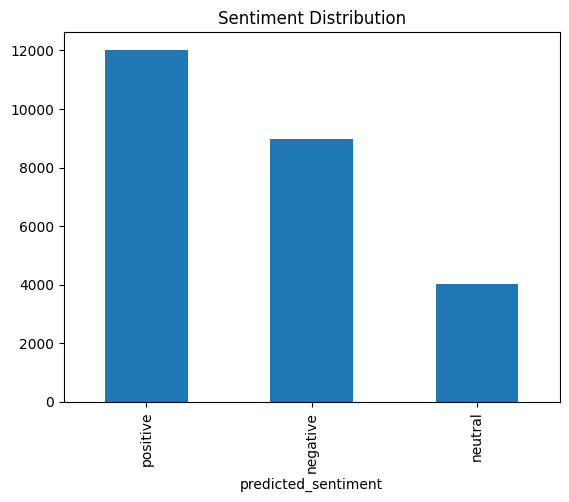

In [11]:
df["predicted_sentiment"].value_counts().plot(kind='bar', title="Sentiment Distribution")

In [12]:
user_text = input("\nEnter a review: ")

score = sia.polarity_scores(user_text)["compound"]

if score >= 0.05:
    sentiment = "positive"
elif score <= -0.05:
    sentiment = "negative"
else:
    sentiment = "neutral"
    
vec = vectorizer.transform([user_text])
row = vec.toarray()[0]
top_idx = row.argsort()[-3:]
keywords = [feature_names[i] for i in top_idx]

print("Sentiment:", sentiment)
print("Keywords:", keywords)


Enter a review:  Product is really good and fast


Sentiment: positive
Keywords: ['worth', 'product', 'fast']


In [13]:
!pip install wordcloud

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [17]:
def generate_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.title(title)
    plt.show()

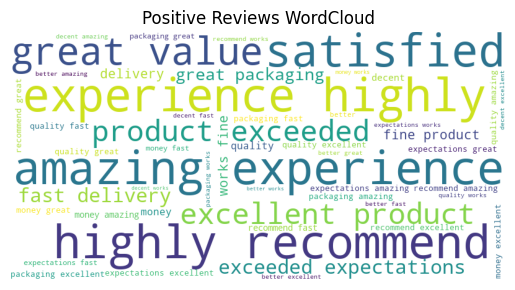

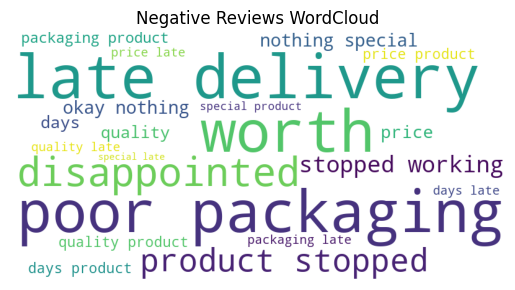

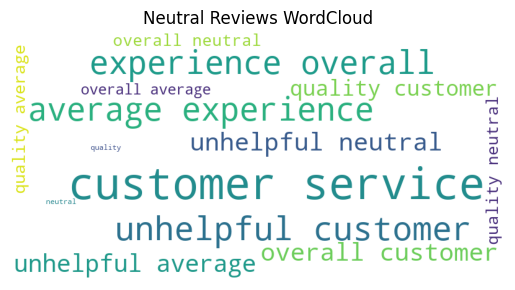

In [18]:
# Combine text by sentiment
pos_text = " ".join(df[df["predicted_sentiment"] == "positive"]["review"])
neg_text = " ".join(df[df["predicted_sentiment"] == "negative"]["review"])
neu_text = " ".join(df[df["predicted_sentiment"] == "neutral"]["review"])

# Generate word clouds
generate_wordcloud(pos_text, "Positive Reviews WordCloud")
generate_wordcloud(neg_text, "Negative Reviews WordCloud")
generate_wordcloud(neu_text, "Neutral Reviews WordCloud")